#### Clustering

##### Importing Libraries and Loading Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import DBSCAN
from pathlib import Path
import joblib

In [2]:
project_root = Path.cwd().parent
processed_dir = project_root/'data'/'processed'
models_dir = project_root/'models'
figures_dir = project_root/'reports'/'figures'

In [3]:
features = pd.read_parquet(processed_dir/'station_features.parquet')

In [4]:
features_scaled = pd.read_parquet(processed_dir/'station_features_scaled.parquet')

In [5]:
station_dim = pd.read_parquet(processed_dir/'station_dimension.parquet').set_index('nlc')

In [6]:
features_scaled.head()

,log_total_weekday,early_share,eve_share,late_share,peakness,am_asym,pm_asym,weekend_shift,weekend_ratio,lines_served,interchange_ratio
nlc,,,,,,,,,,,
750,-0.862447,0.243759,0.337337,0.641688,-0.663250,-0.305477,0.400954,-0.427657,0.003162,0.0,0.000000
1404,-0.725928,0.169494,0.120946,0.192606,-0.232571,-0.342659,0.082545,0.114390,-0.297051,0.0,0.000000
3000,-0.104848,0.184460,-0.327957,-0.298239,0.265232,0.159342,-0.020733,0.350321,0.337970,0.0,0.000000
500,0.186290,-0.048123,-0.219895,-0.031235,0.048782,-0.082235,0.179439,-0.141977,0.157152,1.0,13.638486
502,0.578366,-0.504523,0.835659,0.723786,0.762086,-1.453377,1.220046,-0.005377,-1.331137,1.0,0.560999


In [7]:
features_scaled.shape

(432, 11)

##### K-Means Clustering

In [8]:
# Checking Inertia and Silhouette Scores between K range 2-11

k_range = range(2, 11)
inertias = []
silhouettes = []

In [9]:
# Fitting K-Means models in the range

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=69)
    labels = km.fit_predict(features_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(features_scaled, labels))

C:\Users\Abdul Qudus\anaconda3\envs\london-transit\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abdul Qudus\anaconda3\envs\london-transit\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abdul Qudus\anaconda3\envs\london-transit\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abdul Qudus\anaconda3\envs\london-transit\Lib\sit

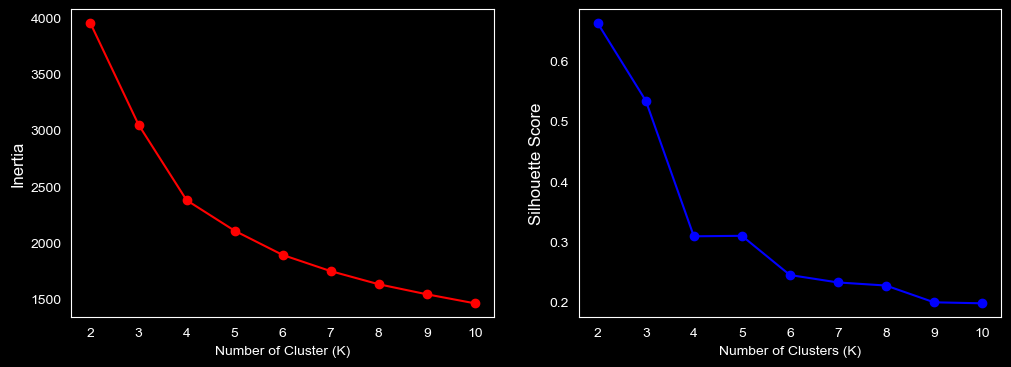

In [28]:
# Visualising the Inertia and Silhouette Score metrics

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))

ax1.plot(list(k_range), inertias, marker='o', color='red')
ax1.set_xlabel('Number of Cluster (K)')
ax1.set_ylabel('Inertia', fontsize=12)
ax1.grid(False)

ax2.plot(list(k_range), silhouettes, marker='o', color='blue')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.grid(False)

plt.savefig(figures_dir/'k_means_metrics.png', dpi=120)
plt.show()


In [11]:
# Fitting the Final Model of K = 6

K = 6
kmeans = KMeans(n_clusters=6, n_init=10, random_state=69)

In [12]:
features['cluster_k'] = kmeans.fit_predict(features_scaled)

C:\Users\Abdul Qudus\anaconda3\envs\london-transit\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [13]:
features.groupby('cluster_k').mean().round(3)

,log_total_weekday,early_share,eve_share,late_share,peakness,am_asym,pm_asym,weekend_shift,weekend_ratio,lines_served,interchange_ratio
cluster_k,,,,,,,,,,,
0,8.272,0.121,0.042,0.011,0.050,0.556,-0.405,0.337,0.724,1.065,0.004
1,9.716,0.052,0.104,0.039,0.036,0.150,-0.073,0.231,0.864,2.450,0.706
2,9.544,0.074,0.075,0.033,0.042,0.343,-0.237,0.293,0.813,1.600,0.264
3,8.661,0.058,0.085,0.029,0.035,0.185,-0.073,0.245,0.831,1.115,0.013
4,10.563,0.012,0.185,0.102,0.036,-0.526,0.225,0.161,0.942,2.833,0.448
5,9.401,0.019,0.154,0.068,0.038,-0.475,0.281,0.182,0.775,1.407,0.008


In [14]:
features['cluster_k'].value_counts()

cluster_k
3    157
0    138
5     59
2     40
1     20
4     18
Name: count, dtype: int64

In [15]:
# Saving

joblib.dump(kmeans, models_dir/'kmeans.joblib')

['C:\\Users\\Abdul Qudus\\Documents\\Data Portfolio\\london-transit-archetypes\\models\\kmeans.joblib']

##### Hierarchical Clustering

In [16]:
# Creating the Linkage Matrix

linkage_matrix = linkage(features_scaled, method='ward')

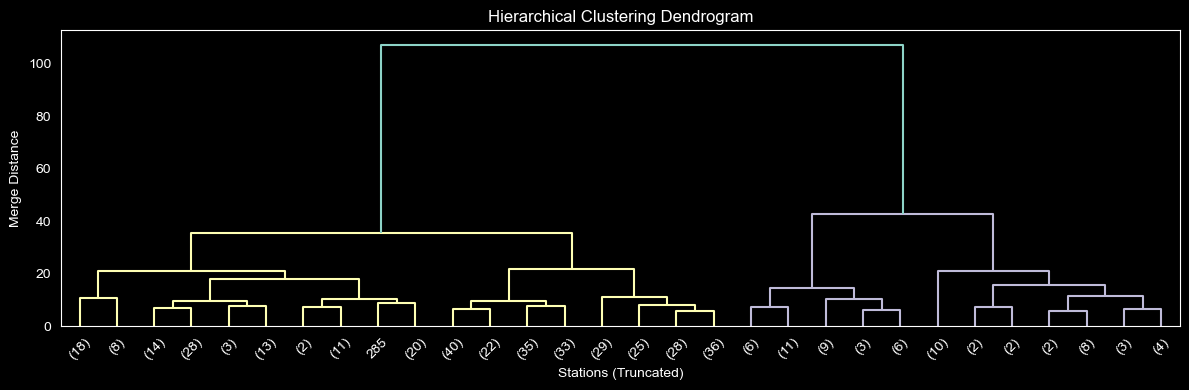

In [29]:
# Creating the Dendrogram of the last 30 merges

plt.figure(figsize=(12, 4))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Stations (Truncated)')
plt.ylabel('Merge Distance')

plt.grid(False)
plt.tight_layout()

plt.savefig(figures_dir/'dendrogram.png', dpi=120)
plt.show()


In [18]:
features['cluster_hier'] = fcluster(linkage_matrix, t=6, criterion='maxclust')

In [19]:
features['cluster_hier'].value_counts()

cluster_hier
3    130
4    118
2     92
5     35
6     31
1     26
Name: count, dtype: int64

In [20]:
# Comparing with K-Means

pd.crosstab(features['cluster_k'], features['cluster_hier'])

cluster_hier,1,2,3,4,5,6
cluster_k,,,,,,
0,0,0,23,115,0,0
1,0,0,0,0,0,20
2,11,0,0,0,29,0
3,13,34,107,3,0,0
4,1,0,0,0,6,11
5,1,58,0,0,0,0


##### DBSCAN

In [21]:
dbscan = DBSCAN(eps=1.5, min_samples=5)

In [22]:
features['cluster_dbscan'] = dbscan.fit_predict(features_scaled)

In [23]:
# -1 is what DBSCAN identified as Noise Points

features['cluster_dbscan'].value_counts()

cluster_dbscan
 0    321
-1    106
 1      5
Name: count, dtype: int64

In [24]:
# Adding Station names

named_features = features.join(station_dim['station_name'])

In [25]:
named_features.head()

,log_total_weekday,early_share,eve_share,late_share,peakness,am_asym,pm_asym,weekend_shift,weekend_ratio,lines_served,interchange_ratio,cluster_k,cluster_hier,cluster_dbscan,station_name
nlc,,,,,,,,,,,,,,,
750,7.760586,0.077621,0.094472,0.041111,0.030217,0.139383,-0.006690,0.213420,0.783216,1,0.000000,3,3,0,Abbey Road
1404,7.923830,0.071789,0.080898,0.027622,0.036185,0.116857,-0.139332,0.267944,0.725684,1,0.000000,3,3,0,Acton Central
3000,8.666488,0.072965,0.052739,0.012879,0.043083,0.420971,-0.182355,0.291676,0.847376,1,0.000000,3,4,0,Acton Main Line
500,9.014619,0.054701,0.059517,0.020899,0.040084,0.274624,-0.098968,0.242156,0.812725,2,0.609405,1,6,-1,Acton Town
502,9.483445,0.018862,0.125731,0.043576,0.049968,-0.556020,0.334524,0.255896,0.527519,2,0.025067,5,2,0,Aldgate


In [26]:
named_features.shape

(432, 15)

In [27]:
# Saving the full dataframe
named_features.to_parquet(processed_dir/'station_clusters_full.parquet')